In [61]:
# MILESTONE - 2
# Temporal Trend Analysis of US Disaster Declarations
# STEP 1: Import Required Libraries
import pandas as pd              # For data manipulation
import numpy as np               # For numerical operations
import matplotlib.pyplot as plt  # For visualization
import seaborn as sns            # For advanced visualization

plt.style.use("default")         # Clean plotting style

In [63]:
# STEP 2: Load Dataset
# Load CSV file from data folder
df = pd.read_csv("../data/us_disaster_declarations.csv")

# Display first 5 rows
df.head()

,fema_declaration_string,disaster_number,state,declaration_type,declaration_date,fy_declared,incident_type,declaration_title,ih_program_declared,ia_program_declared,...,place_code,designated_area,declaration_request_number,last_ia_filing_date,incident_id,region,designated_incident_types,last_refresh,hash,id
0,DR-1-GA,1,GA,DR,1953-05-02T00:00:00Z,1953,Tornado,Tornado,0,1,...,0,Statewide,53013,NaN,53013,4,NaN,2024-08-27T18:22:14Z,413ff808d79f08a6710f6b78f361d5a7de692711,8943dfcf-9786-4e51-8889-d62014034bb2
1,DR-2-TX,2,TX,DR,1953-05-15T00:00:00Z,1953,Tornado,Tornado & Heavy Rainfall,0,1,...,0,Statewide,53003,NaN,53003,6,W,2024-08-27T18:22:14Z,8a8bc885c003cb873c201bb6a3a2771a6d84efb1,ff821327-6b90-4246-b19f-fff8c4b288a8
2,DR-3-LA,3,LA,DR,1953-05-29T00:00:00Z,1953,Flood,Flood,0,1,...,0,Statewide,53005,NaN,53005,6,NaN,2024-08-27T18:22:14Z,b6e6f19ae3c0d2383b7b873b8495bd2770f2ff9a,cd461e08-5ac9-4e70-8507-9c7a3cbff265
3,DR-4-MI,4,MI,DR,1953-06-02T00:00:00Z,1953,Tornado,Tornado,0,1,...,0,Statewide,53004,NaN,53004,5,NaN,2024-08-27T18:22:14Z,34f0061012c8069f145d56a3537cd327b7d4e49b,53be0c04-d2ae-42fb-b070-a01b0a50b7f6
4,DR-5-MT,5,MT,DR,1953-06-06T00:00:00Z,1953,Flood,Floods,0,1,...,0,Statewide,53006,NaN,53006,8,NaN,2024-08-27T18:22:14Z,3bdbec258e4640c3f02971dbc1f9dbc3ebbfc96a,4b3ed0ac-299b-49f0-80d4-9a2a6bacd5a4


In [65]:
# STEP 3: Validate Time Data (MANDATORY)
# Convert declaration_date column into datetime format
# errors='coerce' will convert invalid dates into NaT
df['declaration_date'] = pd.to_datetime(df['declaration_date'], errors='coerce')

# Check for missing or invalid dates
df['declaration_date'].isnull().sum()

0

In [67]:
# STEP 4: Extract year and month from declaration_date

df['year'] = df['declaration_date'].dt.year
df['month'] = df['declaration_date'].dt.month

# Confirm new columns created
df[['declaration_date','year','month']].head()

,declaration_date,year,month
0,1953-05-02 00:00:00+00:00,1953,5
1,1953-05-15 00:00:00+00:00,1953,5
2,1953-05-29 00:00:00+00:00,1953,5
3,1953-06-02 00:00:00+00:00,1953,6
4,1953-06-06 00:00:00+00:00,1953,6


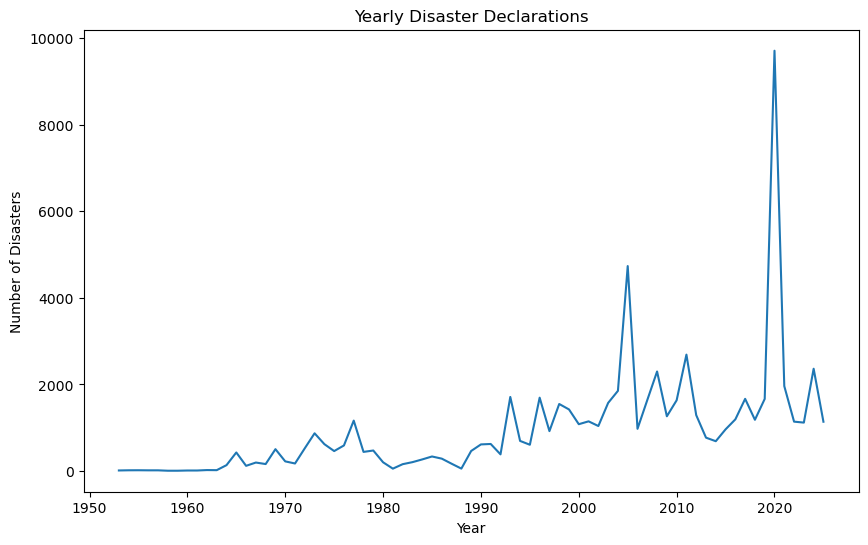

In [69]:
# STEP 5: Yearly Trend Analysis
# Group data by year and count number of disasters
yearly = df.groupby('year').size()

# Plot yearly trend
plt.figure(figsize=(10,6))
yearly.plot()

plt.title("Yearly Disaster Declarations")
plt.xlabel("Year")
plt.ylabel("Number of Disasters")

plt.show()

<Figure size 1400x800 with 0 Axes>

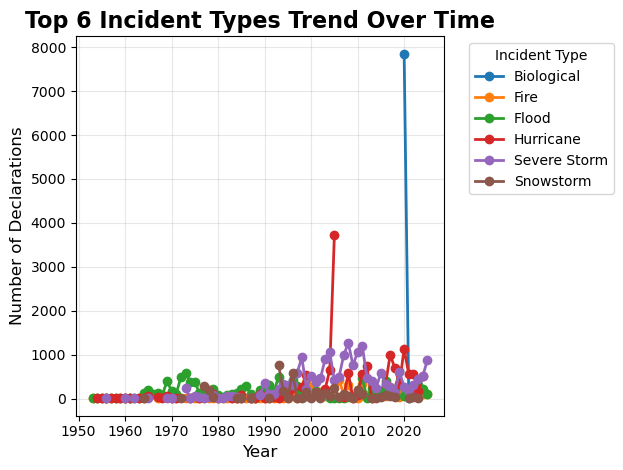

In [83]:
# STEP 6: Incident Type Trend Over Time
# 1️⃣ Select Top 6 most frequent incident types
top_types = df['incident_type'].value_counts().head(6).index

filtered_df = df[df['incident_type'].isin(top_types)]

# 2️⃣ Group data
incident_trend = (
    filtered_df
    .groupby(['year', 'incident_type'])
    .size()
    .unstack()
)

# 3️⃣ Plot
plt.figure(figsize=(14,8))

incident_trend.plot(
    linewidth=2,
    marker='o'
)

plt.title("Top 6 Incident Types Trend Over Time", fontsize=16, fontweight='bold')
plt.xlabel("Year", fontsize=12)
plt.ylabel("Number of Declarations", fontsize=12)

plt.grid(alpha=0.3)
plt.legend(title="Incident Type", bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

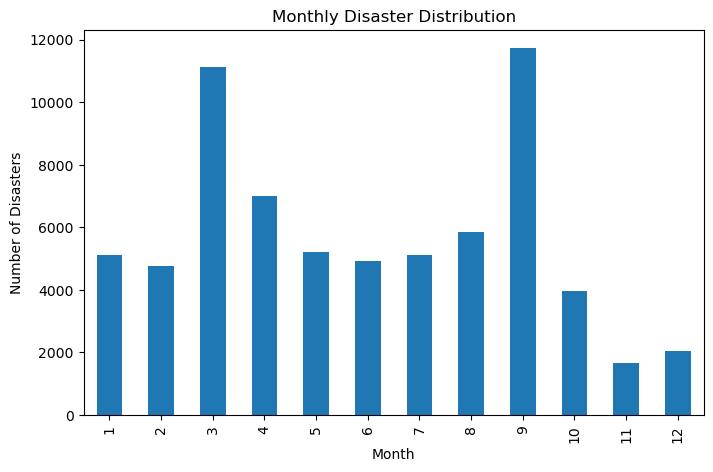

In [73]:
# STEP 7: Monthly Seasonality Analysis
# Group by month
monthly = df.groupby('month').size()

# Plot bar chart
plt.figure(figsize=(8,5))
monthly.plot(kind='bar')

plt.title("Monthly Disaster Distribution")
plt.xlabel("Month")
plt.ylabel("Number of Disasters")

plt.show()

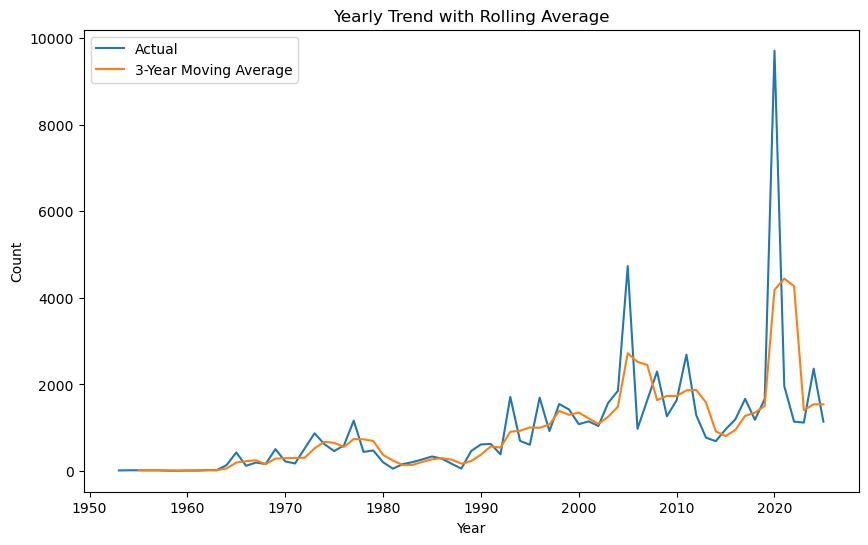

In [75]:
# STEP 8: Rolling Average (Advanced Insight)
# Apply 3-year moving average to smooth noise
rolling_avg = yearly.rolling(window=3).mean()

plt.figure(figsize=(10,6))
yearly.plot(label="Actual")
rolling_avg.plot(label="3-Year Moving Average")

plt.title("Yearly Trend with Rolling Average")
plt.xlabel("Year")
plt.ylabel("Count")
plt.legend()

plt.show()

In [77]:
# STEP 9: Growth Rate (Year-over-Year Percentage Change)
growth_rate = yearly.pct_change() * 100

growth_rate.head()

year
1953          NaN
1954    30.769231
1955     5.882353
1956   -11.111111
1957     0.000000
dtype: float64

In [79]:
# STEP 10: Peak Detection (Top 5 Years)
top_years = yearly.sort_values(ascending=False).head()

top_years

year
2020    9712
2005    4736
2011    2690
2024    2364
2008    2300
dtype: int64